In [1]:
from DFTStructureGenerator.descriptor import (
    DUPLICATE_CL_IDS,
    DUPLICATE_N_IDS,
    build_descriptor_maps,
    dataframe_to_descriptors,
    load_descriptor_maps,
    save_descriptor_maps,
)
import numpy as np
from tqdm import tqdm
import pandas as pd


In [2]:
%load_ext autoreload
%autoreload 2
%matplotlib inline
import warnings 
warnings.filterwarnings("ignore")

In [3]:
from catboost import CatBoostRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import KFold
import pickle
np.random.seed(0)

In [4]:
from matplotlib import pyplot as plt
from DFTStructureGenerator.draw import (
    draw_correlation_map,
    plot_scatter_with_metrics,
)


In [5]:
duplicate_N_id = DUPLICATE_N_IDS
duplicate_Cl_id = DUPLICATE_CL_IDS


In [6]:
DB_PATH = "boron_ccl2.db"
BN_CSV_PATH = "data/csvs/reactants_B_N.csv"
CL_CSV_PATH = "data/csvs/reactants_Cl.csv"
BN_DESCRIPTOR_PATH = "Data/descriptor/BNdes_new2.pkl"
CL_DESCRIPTOR_PATH = "Data/descriptor/Cldes_new2.pkl"

# Descriptor Generation

In [ ]:
B_N_des_map, Cl_des_map = build_descriptor_maps(
    db_path=DB_PATH,
    bn_csv_path=BN_CSV_PATH,
    cl_csv_path=CL_CSV_PATH,
    duplicate_cl_ids=duplicate_Cl_id,
)


In [ ]:
save_descriptor_maps(
    B_N_des_map,
    Cl_des_map,
    bn_path=BN_DESCRIPTOR_PATH,
    cl_path=CL_DESCRIPTOR_PATH,
)


# Feature Loading

In [8]:
B_N_des_map, Cl_des_map = load_descriptor_maps(
    bn_path=BN_DESCRIPTOR_PATH,
    cl_path=CL_DESCRIPTOR_PATH,
)


# Training model

In [9]:
# Combined quantitative features
data_csv = pd.read_csv(r"Data\TS\Borane_all.csv")
y = data_csv["deltaGa(kcal/mol)"]
target_eng = data_csv["deltaGa(kcal/mol)"]
all_Xs = dataframe_to_descriptors(
    data_csv,
    B_N_des_map,
    Cl_des_map,
    duplicate_cl_ids=duplicate_Cl_id,
)


100%|██████████| 9237/9237 [00:00<00:00, 35511.59it/s]


In [10]:
np.array(all_Xs).shape

(9237, 18)

# Descriptor Correlation

Max correlation:  0.8949314973189016


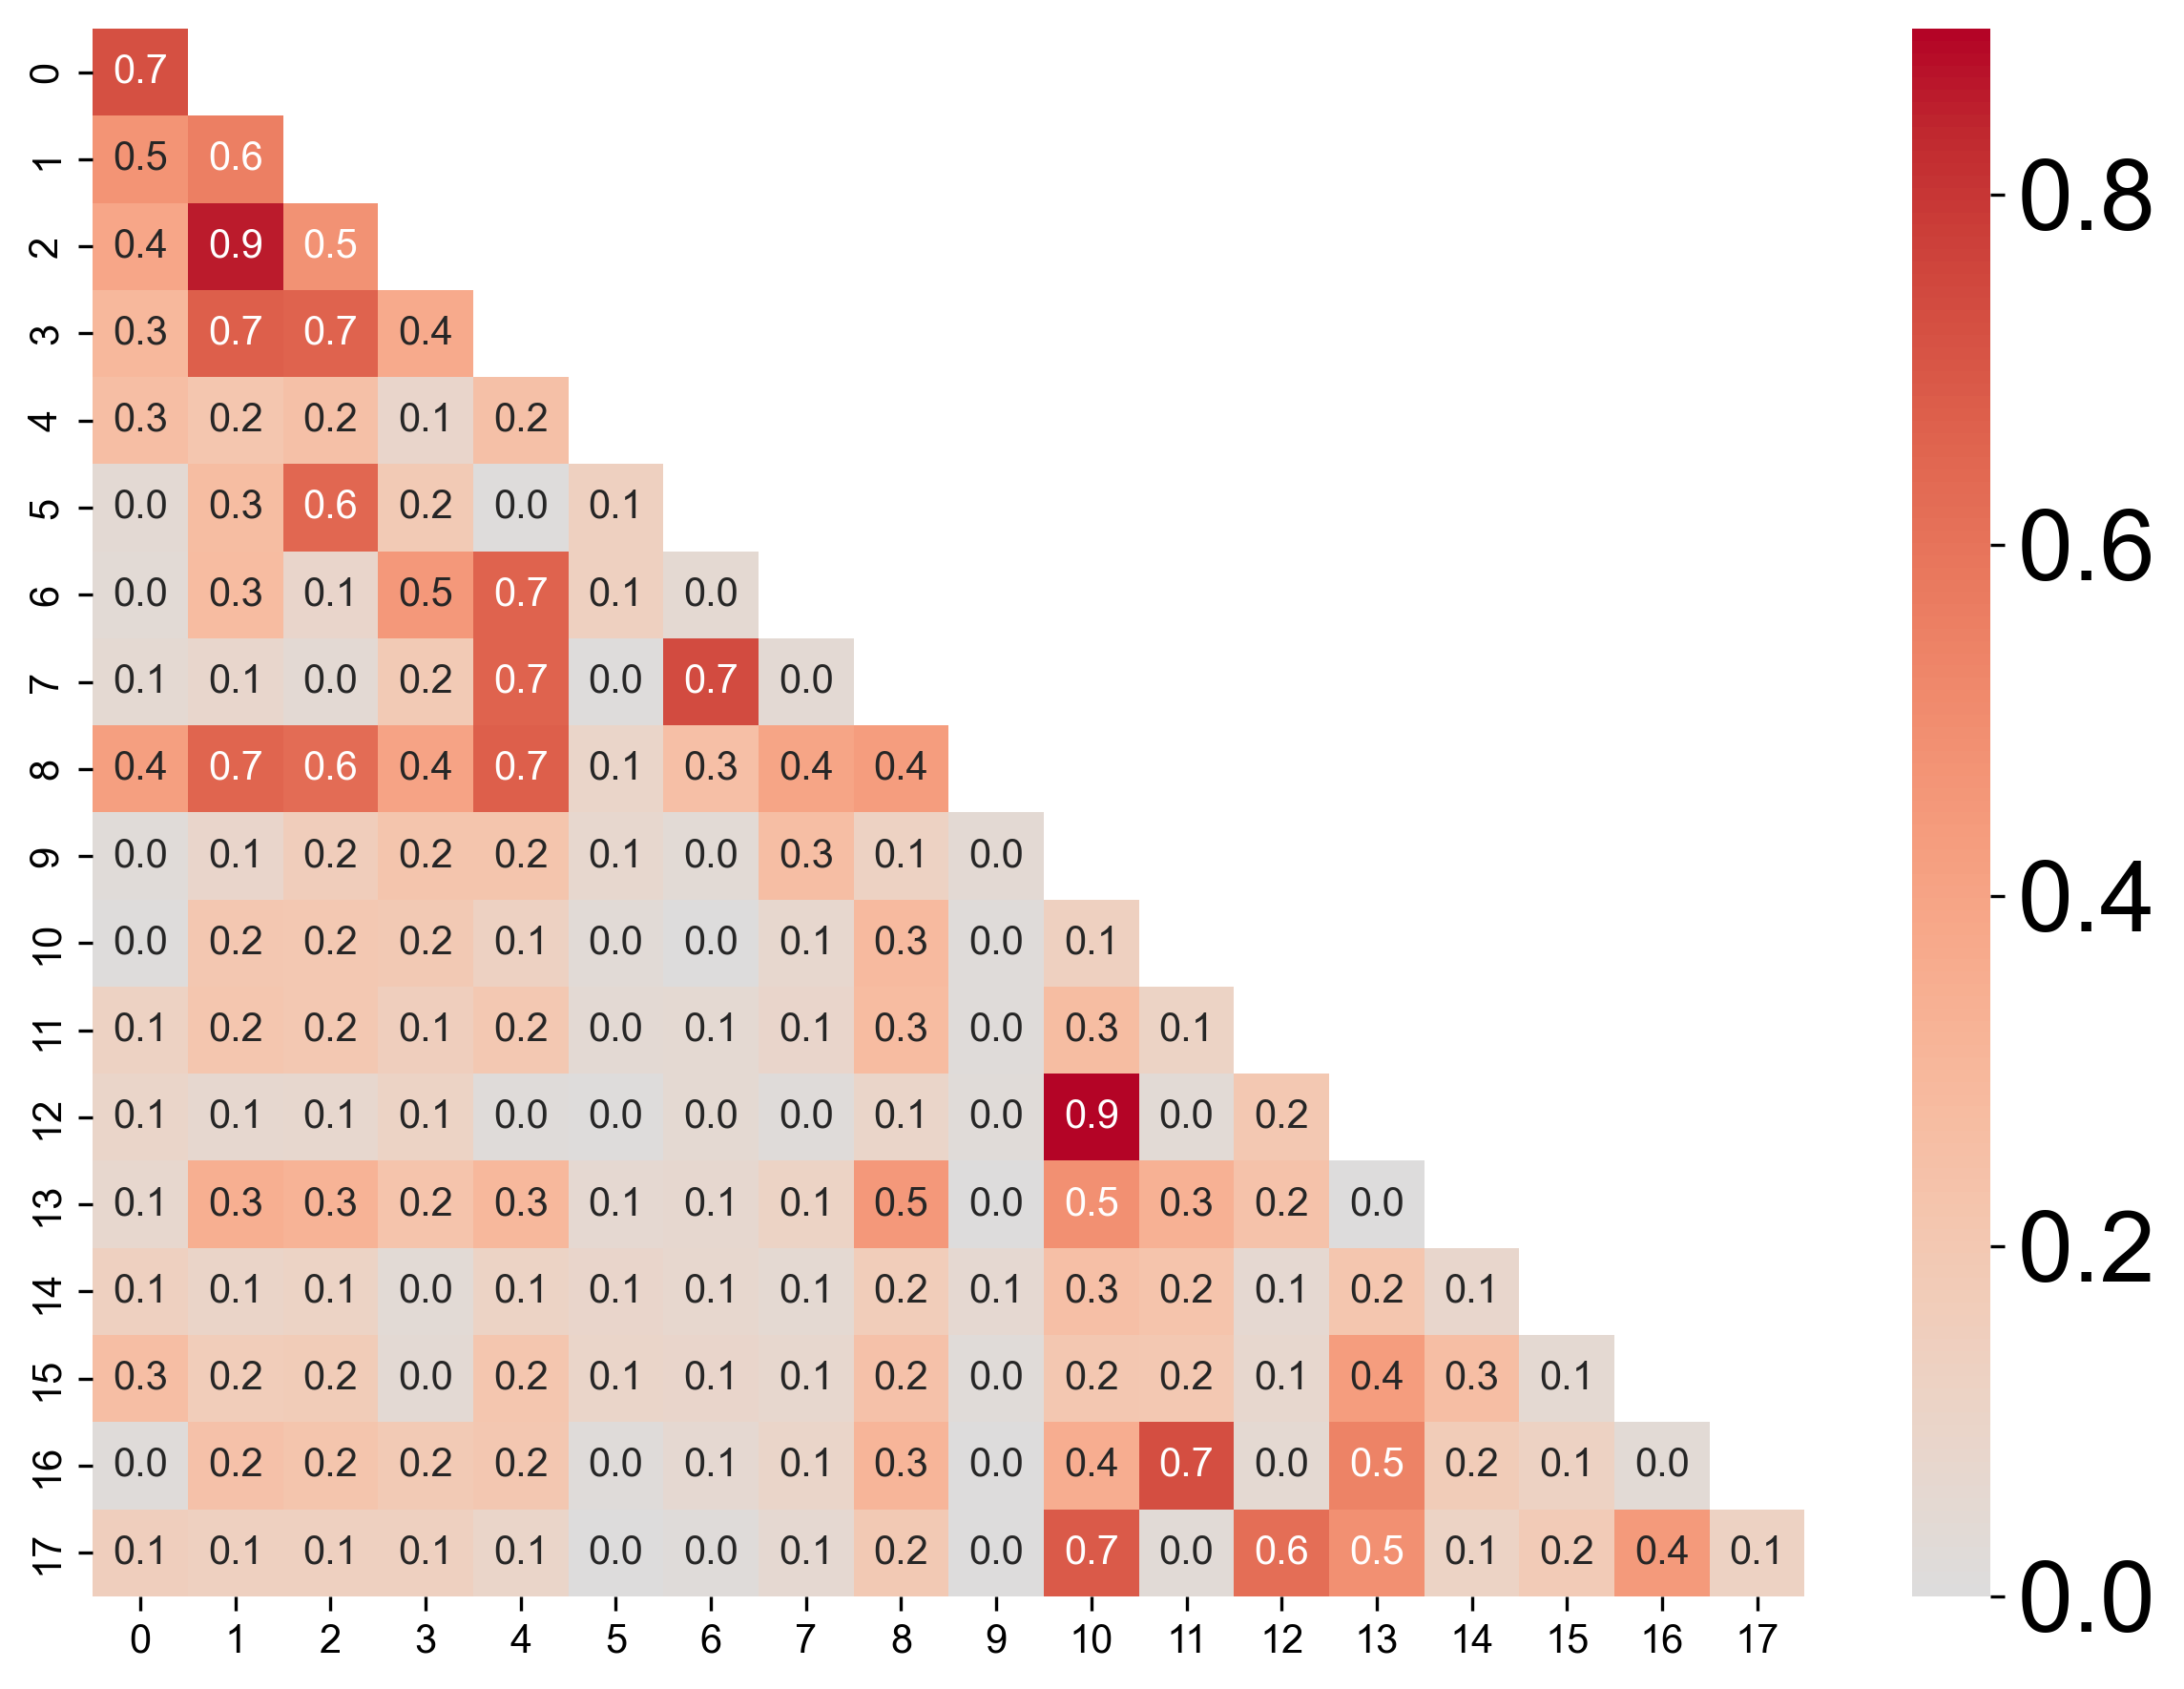

In [11]:
correlation_matrix = draw_correlation_map(all_Xs, figure_size=(8, 6), colors='coolwarm', annot=True, show_label=True, target = y.to_numpy())

# 5-Fold Validation

In [12]:
all_X = np.array(all_Xs)
y = data_csv['deltaGa(kcal/mol)'].to_numpy()
kf = KFold(n_splits=5, shuffle=True, random_state=0)
all_r2s = []
all_pred = [0 for _ in range(len(all_X))]
for train_ids, test_ids in list(kf.split(all_X)):
    model = CatBoostRegressor(iterations=10000, learning_rate=0.01, depth=6, verbose=0, random_state = 0)
    # model = RandomForestRegressor()
    model.fit(all_X[train_ids], y[train_ids])
    y_pred = model.predict(all_X[test_ids])
    print(f"R2: {r2_score(y[test_ids], y_pred):.3f}, MAE: {mean_absolute_error(y[test_ids], y_pred):.3f}, MSE: {mean_squared_error(y[test_ids], y_pred):.3f}")
    all_r2s.append(r2_score(y[test_ids], y_pred))
    for test_id, y_p in zip(test_ids, y_pred):
        all_pred[test_id] = y_p
print(f"Mean of 5-Fold R2: {np.mean(all_r2s):.3f}")

R2: 0.892, MAE: 1.415, MSE: 4.311
R2: 0.903, MAE: 1.430, MSE: 3.948
R2: 0.904, MAE: 1.404, MSE: 3.740
R2: 0.914, MAE: 1.338, MSE: 3.439
R2: 0.917, MAE: 1.370, MSE: 3.467
Mean of 5-Fold R2: 0.906


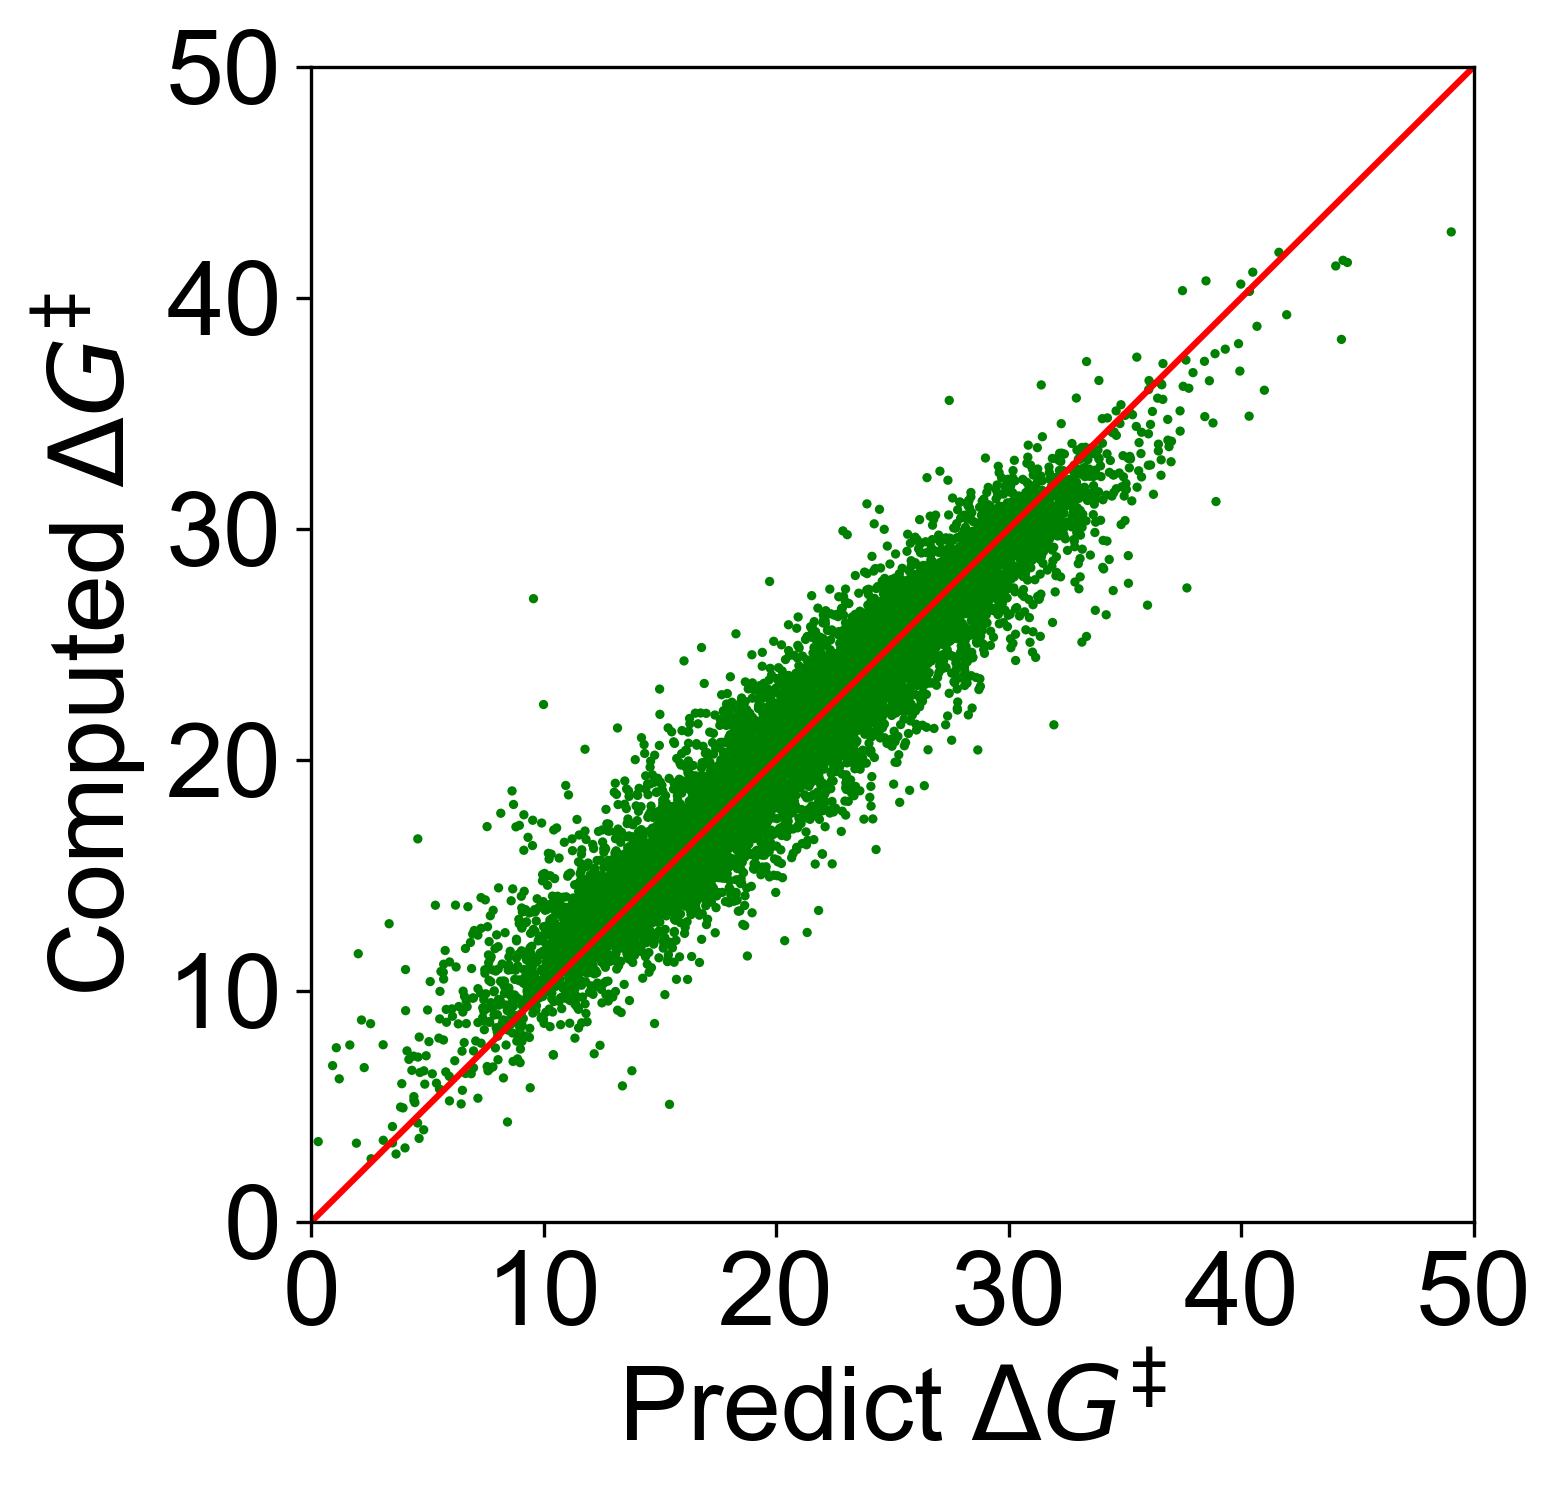

In [12]:
plot_scatter_with_metrics(y, all_pred, min_=0, max_=50)


In [13]:
model = CatBoostRegressor(iterations=10000, learning_rate=0.01, depth=6, verbose=0, random_state = 0)
model.fit(all_Xs, y)
FI = model.feature_importances_

In [14]:
des_name_std_sorted = [
    '$\\Delta G_{\\mathrm{rxn}}$',                 # deltaG
    'LB-B· $P^{\\mathrm{spin}}$',                  # B_N B_spin
    'LB-B· $q^{\\mathrm{B}}_{\\mathrm{H}}$',       # B_N B_Hirshfield_charge
    'LB-B· $d_{\\mathrm{LB-B}}$',                  # B_N B_N_dist
    'LB-B· $E_{\\mathrm{SOMO}}$',                  # B_N Alpha-HOMO
    'LB-B-Cl $q^{\\mathrm{B}}_{\\mathrm{H}}$',     # B_N_Cl B_Hirshfield_charge
    'LB-B-Cl $q^{\\mathrm{Cl}}_{\\mathrm{H}}$',    # B_N_Cl Cl_Hirshfield_charge
    'LB-B· $d_{\\mathrm{B-Cl}}$',                  # B_N_Cl N_Cl_dist
    'LB-B-Cl $E_{\\mathrm{LUMO}}$',                # B_N_Cl LUMO
    'LB-B-Cl $\\%V_{\\mathrm{bur}}$',              # B_N_Cl Bv6radius
    'Cl-C $q^{\\mathrm{Cl}}_{\\mathrm{H}}$',       # C_Cl Cl_Hirshfield_charge
    'Cl-C $q^{\\mathrm{C}}_{\\mathrm{H}}$',        # C_Cl C_Hirshfield_charge
    'Cl-C $d_{\\mathrm{Cl-C}}$',                   # C_Cl C_Cl_dist
    'Cl-C $E_{\\mathrm{LUMO}}$',                   # C_Cl LUMO
    'C_Cl $\\%V_{\\mathrm{bur}}$',                 # C_Cl Bv6radius
    'C· $P^{\\mathrm{spin}}$',                     # C C_spin
    'C· $q^{\\mathrm{C}}_{\\mathrm{H}}$',          # C C_Hirshfield_charge
    'C· $E_{\\mathrm{SOMO}}$'                      # C Alpha-HOMO
]

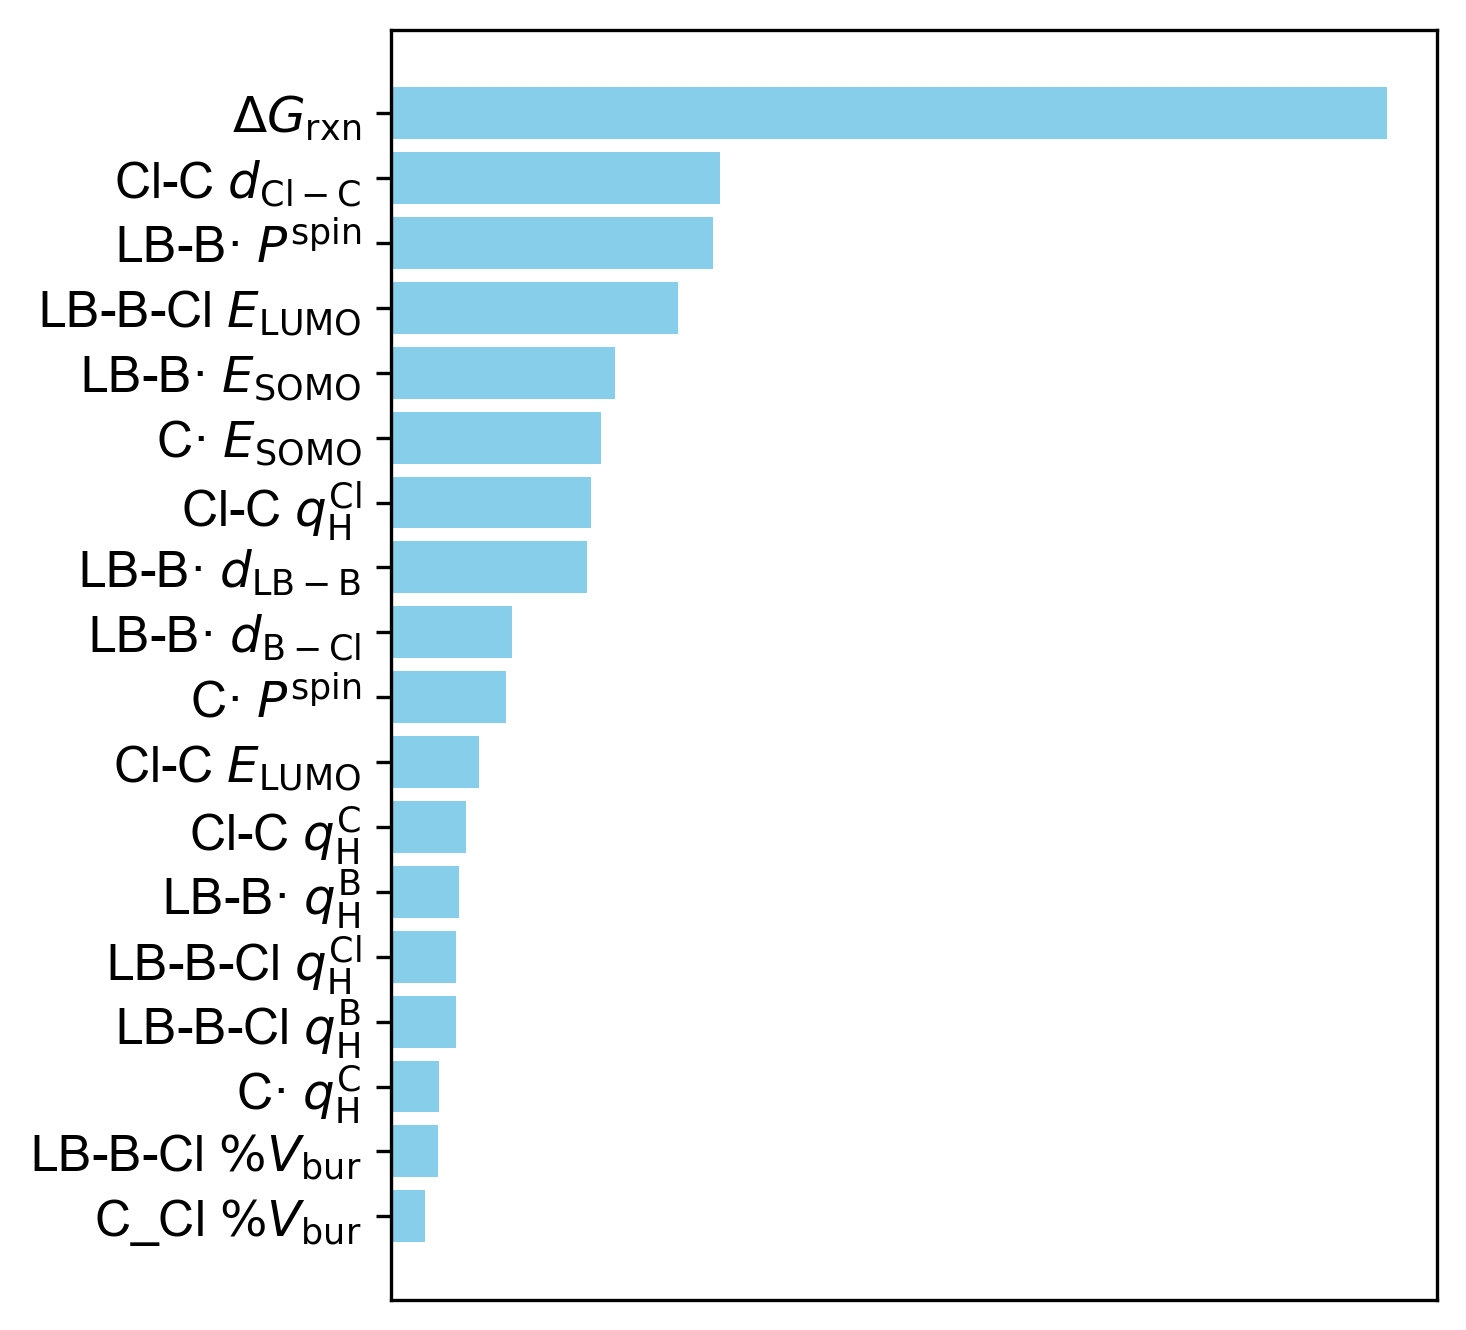

In [15]:
plt.figure(figsize=(4.5,5.5), dpi=300)
plt.rcParams['font.sans-serif'] = 'Arial'
plt.barh(np.array(des_name_std_sorted)[np.argsort(FI)], np.sort(FI), color='skyblue')
# plt.xlabel('Feature Importance')
plt.xticks([])
plt.yticks(fontsize=12)
# plt.ylabel('Features')
# plt.title('Feature Importances')
plt.savefig("Ignored/Feature_Importance.png", dpi=300, bbox_inches='tight')

# Other Seeds

In [27]:
all_X = np.array(all_Xs)
y = data_csv['deltaGa(kcal/mol)'].to_numpy()
kf = KFold(n_splits=5, shuffle=True, random_state=1)

for seed in range(10):
    all_r2s, all_mae, all_mse = [], [], []
    kf = KFold(n_splits=5, shuffle=True, random_state=seed)
    for train_ids, test_ids in list(kf.split(all_X)):
        model = CatBoostRegressor(iterations=10000, learning_rate=0.01, depth=6, verbose=0, random_state = 0)
        # model = RandomForestRegressor()
        model.fit(all_X[train_ids], y[train_ids])
        y_pred = model.predict(all_X[test_ids])
        all_r2s.append(r2_score(y[test_ids], y_pred))
        all_mae.append(mean_absolute_error(y[test_ids], y_pred))
        all_mse.append(mean_squared_error(y[test_ids], y_pred))
    print(f"Seed: {seed}, R2: {np.mean(all_r2s):.3f}, MAE: {np.mean(all_mae):.3f}, MSE: {np.mean(all_mse):.3f}")

Seed: 0, R2: 0.909, MAE: 1.389, MSE: 3.662
Seed: 1, R2: 0.907, MAE: 1.394, MSE: 3.716
Seed: 2, R2: 0.906, MAE: 1.390, MSE: 3.789
Seed: 3, R2: 0.907, MAE: 1.386, MSE: 3.733
Seed: 4, R2: 0.908, MAE: 1.386, MSE: 3.674
Seed: 5, R2: 0.908, MAE: 1.390, MSE: 3.673
Seed: 6, R2: 0.907, MAE: 1.402, MSE: 3.742
Seed: 7, R2: 0.907, MAE: 1.393, MSE: 3.715
Seed: 8, R2: 0.910, MAE: 1.377, MSE: 3.613
Seed: 9, R2: 0.908, MAE: 1.392, MSE: 3.689


# OOD

## OOD around chlorine substrates

7237it [00:00, 39595.64it/s]
1999it [00:00, 36204.63it/s]
7496it [00:00, 40004.66it/s]
1740it [00:00, 43013.18it/s]
7567it [00:00, 39814.36it/s]
1669it [00:00, 42132.88it/s]
7409it [00:00, 41477.71it/s]
1827it [00:00, 42301.22it/s]
7235it [00:00, 39712.24it/s]
2001it [00:00, 39936.82it/s]


R2: 0.8109193524922607 MAE: 1.8995295107363668


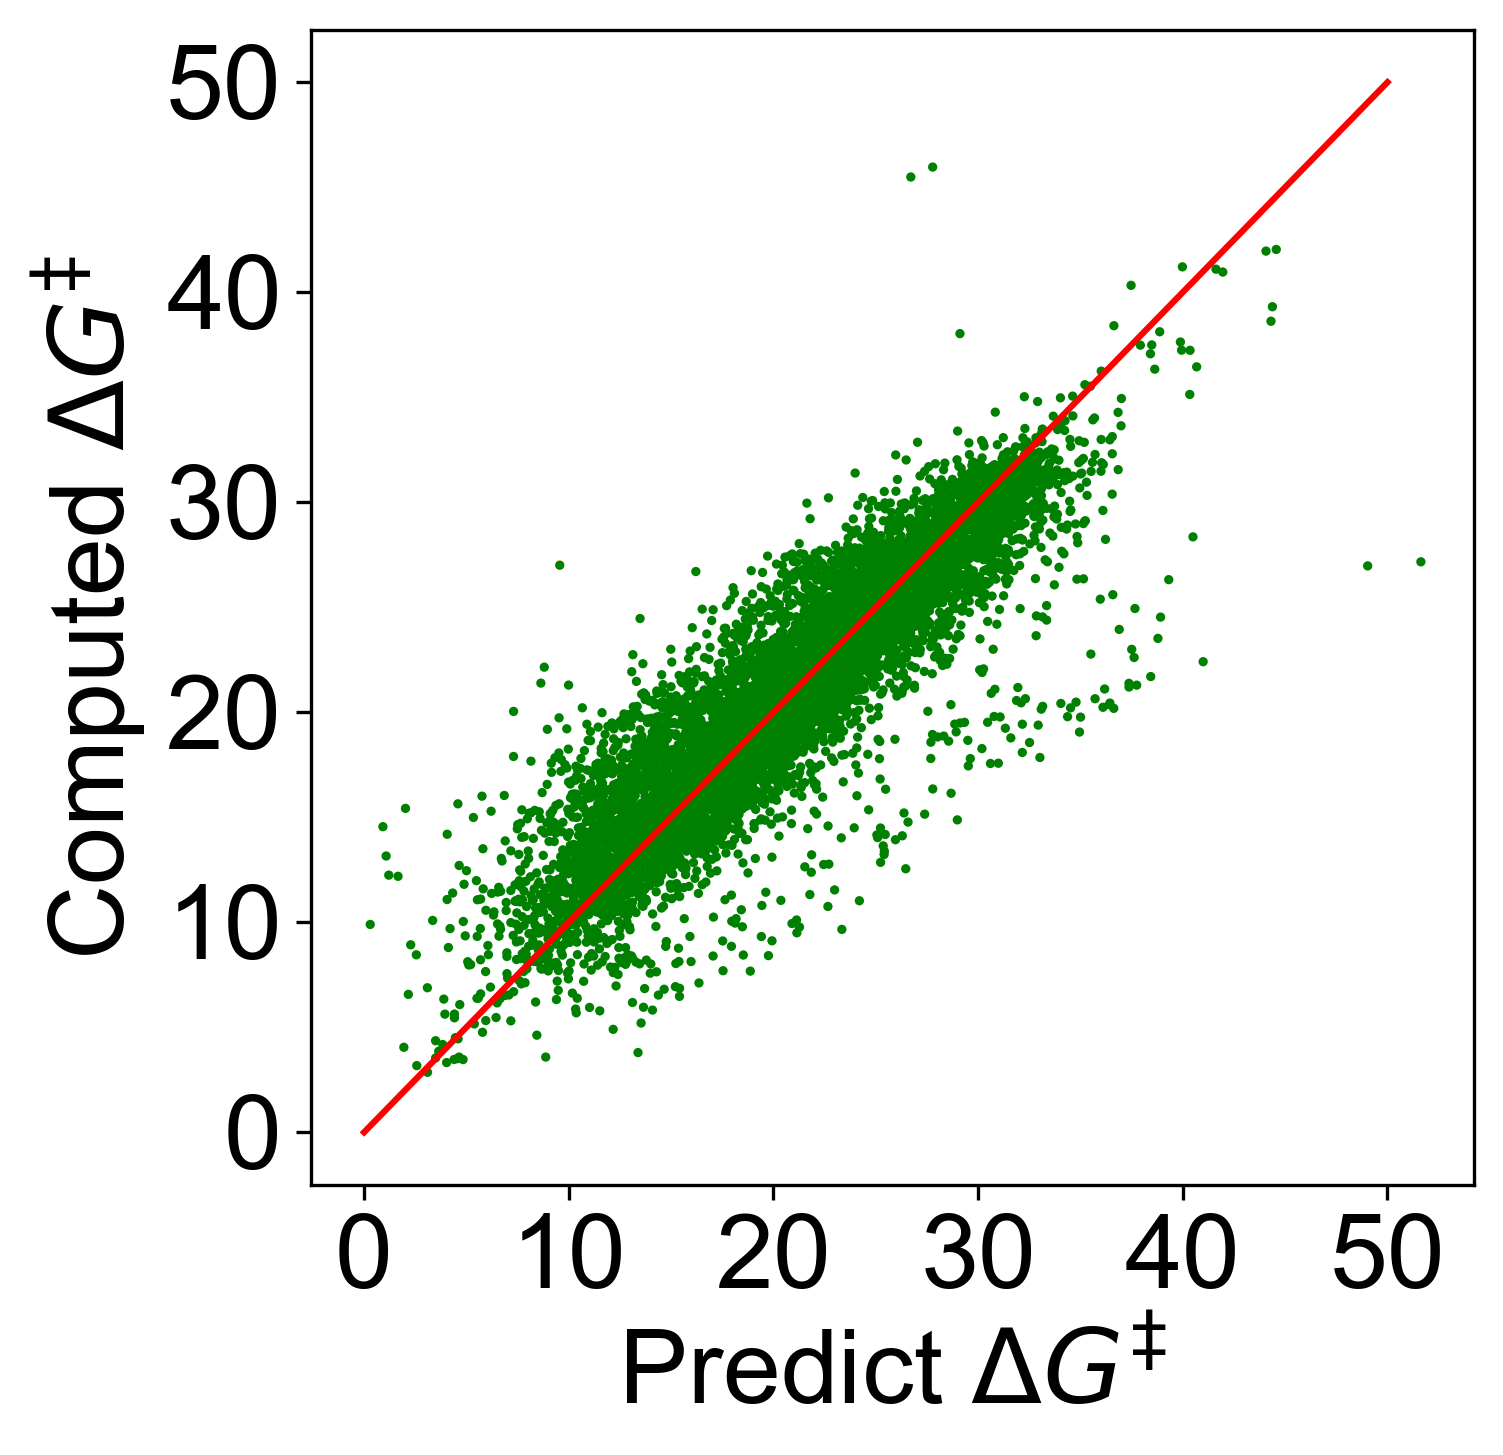

In [51]:
Cl_Indexs = np.sort(data_csv['Cl_Index'].unique())
kf = KFold(n_splits=5, shuffle=True, random_state=0)
all_r2s, all_maes = [], []
all_pred = []
all_real = []
for i, (train_index, test_index) in enumerate(kf.split(Cl_Indexs)):
    train_Cl_index = Cl_Indexs[train_index]
    test_Cl_index = Cl_Indexs[test_index]
    train_df = data_csv.loc[data_csv['Cl_Index'].isin(train_Cl_index)].reset_index(drop=True)
    test_df = data_csv.loc[data_csv['Cl_Index'].isin(test_Cl_index)].reset_index(drop=True)
    train_X = dataframe_to_descriptors(train_df, B_N_des_map, Cl_des_map, duplicate_cl_ids=duplicate_Cl_id)
    test_X = dataframe_to_descriptors(test_df, B_N_des_map, Cl_des_map, duplicate_cl_ids=duplicate_Cl_id)
    train_y = train_df['deltaGa(kcal/mol)']
    test_y = test_df['deltaGa(kcal/mol)']

    model = CatBoostRegressor(iterations=10000, learning_rate=0.01, depth=6, verbose=0, random_state = 0)
    model.fit(train_X, train_y)
    y_pred = model.predict(test_X)
    all_r2s.append(r2_score(test_y, y_pred))
    all_maes.append(mean_absolute_error(test_y, y_pred))
    all_pred.extend(y_pred)
    all_real.extend(test_y.to_numpy())
print("R2:", np.mean(all_r2s), "MAE:", np.mean(all_maes))
plot_scatter_with_metrics(np.array(all_real), np.array(all_pred), min_=0, max_=50)


100%|██████████| 2479/2479 [00:00<00:00, 44927.58it/s]


R2: 0.8666806746578274 MAE: 1.6933979070100282


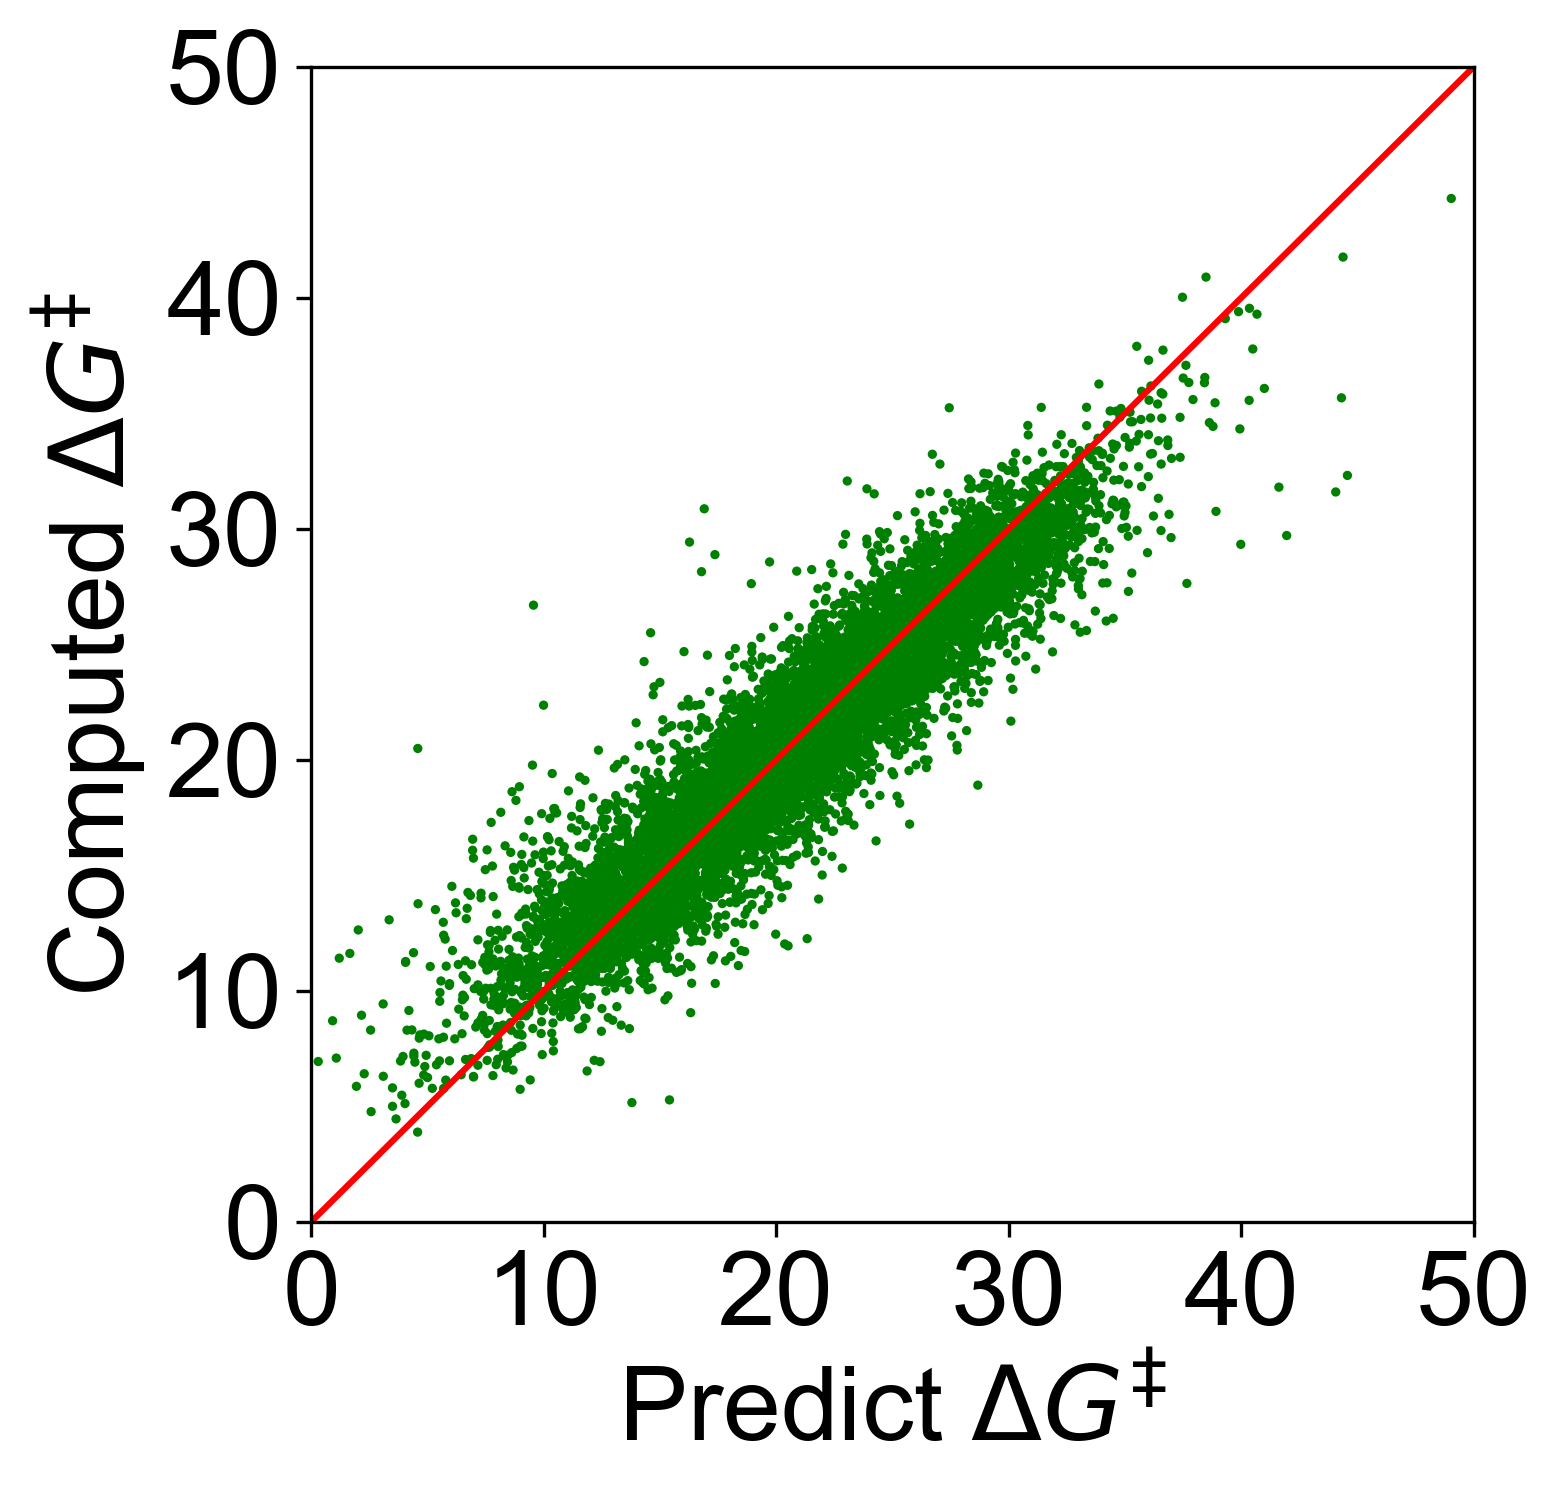

In [28]:
B_Indexs = np.sort(data_csv['B_Index'].unique())
kf = KFold(n_splits=5, shuffle=True, random_state=0)
all_r2s, all_maes = [], []
all_pred = []
all_real = []
for i, (train_index, test_index) in enumerate(kf.split(B_Indexs)):
    train_B_index = B_Indexs[train_index]
    test_B_index = B_Indexs[test_index]
    train_df = data_csv.loc[data_csv['B_Index'].isin(train_B_index)].reset_index(drop=True)
    test_df = data_csv.loc[data_csv['B_Index'].isin(test_B_index)].reset_index(drop=True)
    train_X = dataframe_to_descriptors(train_df, B_N_des_map, Cl_des_map, duplicate_cl_ids=duplicate_Cl_id)
    test_X = dataframe_to_descriptors(test_df, B_N_des_map, Cl_des_map, duplicate_cl_ids=duplicate_Cl_id)
    train_y = train_df['deltaGa(kcal/mol)']
    test_y = test_df['deltaGa(kcal/mol)']   

    model = CatBoostRegressor(iterations=10000, learning_rate=0.01, depth=6, verbose=0, random_state = 0)
    model.fit(train_X, train_y)
    y_pred = model.predict(test_X)
    all_r2s.append(r2_score(test_y, y_pred))
    all_maes.append(mean_absolute_error(test_y, y_pred))
    all_pred.extend(y_pred)
    all_real.extend(test_y.to_numpy())
print("R2:", np.mean(all_r2s), "MAE:", np.mean(all_maes))
plot_scatter_with_metrics(np.array(all_real), np.array(all_pred), min_=0, max_=50)


100%|██████████| 1761/1761 [00:00<00:00, 17414.83it/s]


R2: 0.8655077533550978 MAE: 1.6265959484304922


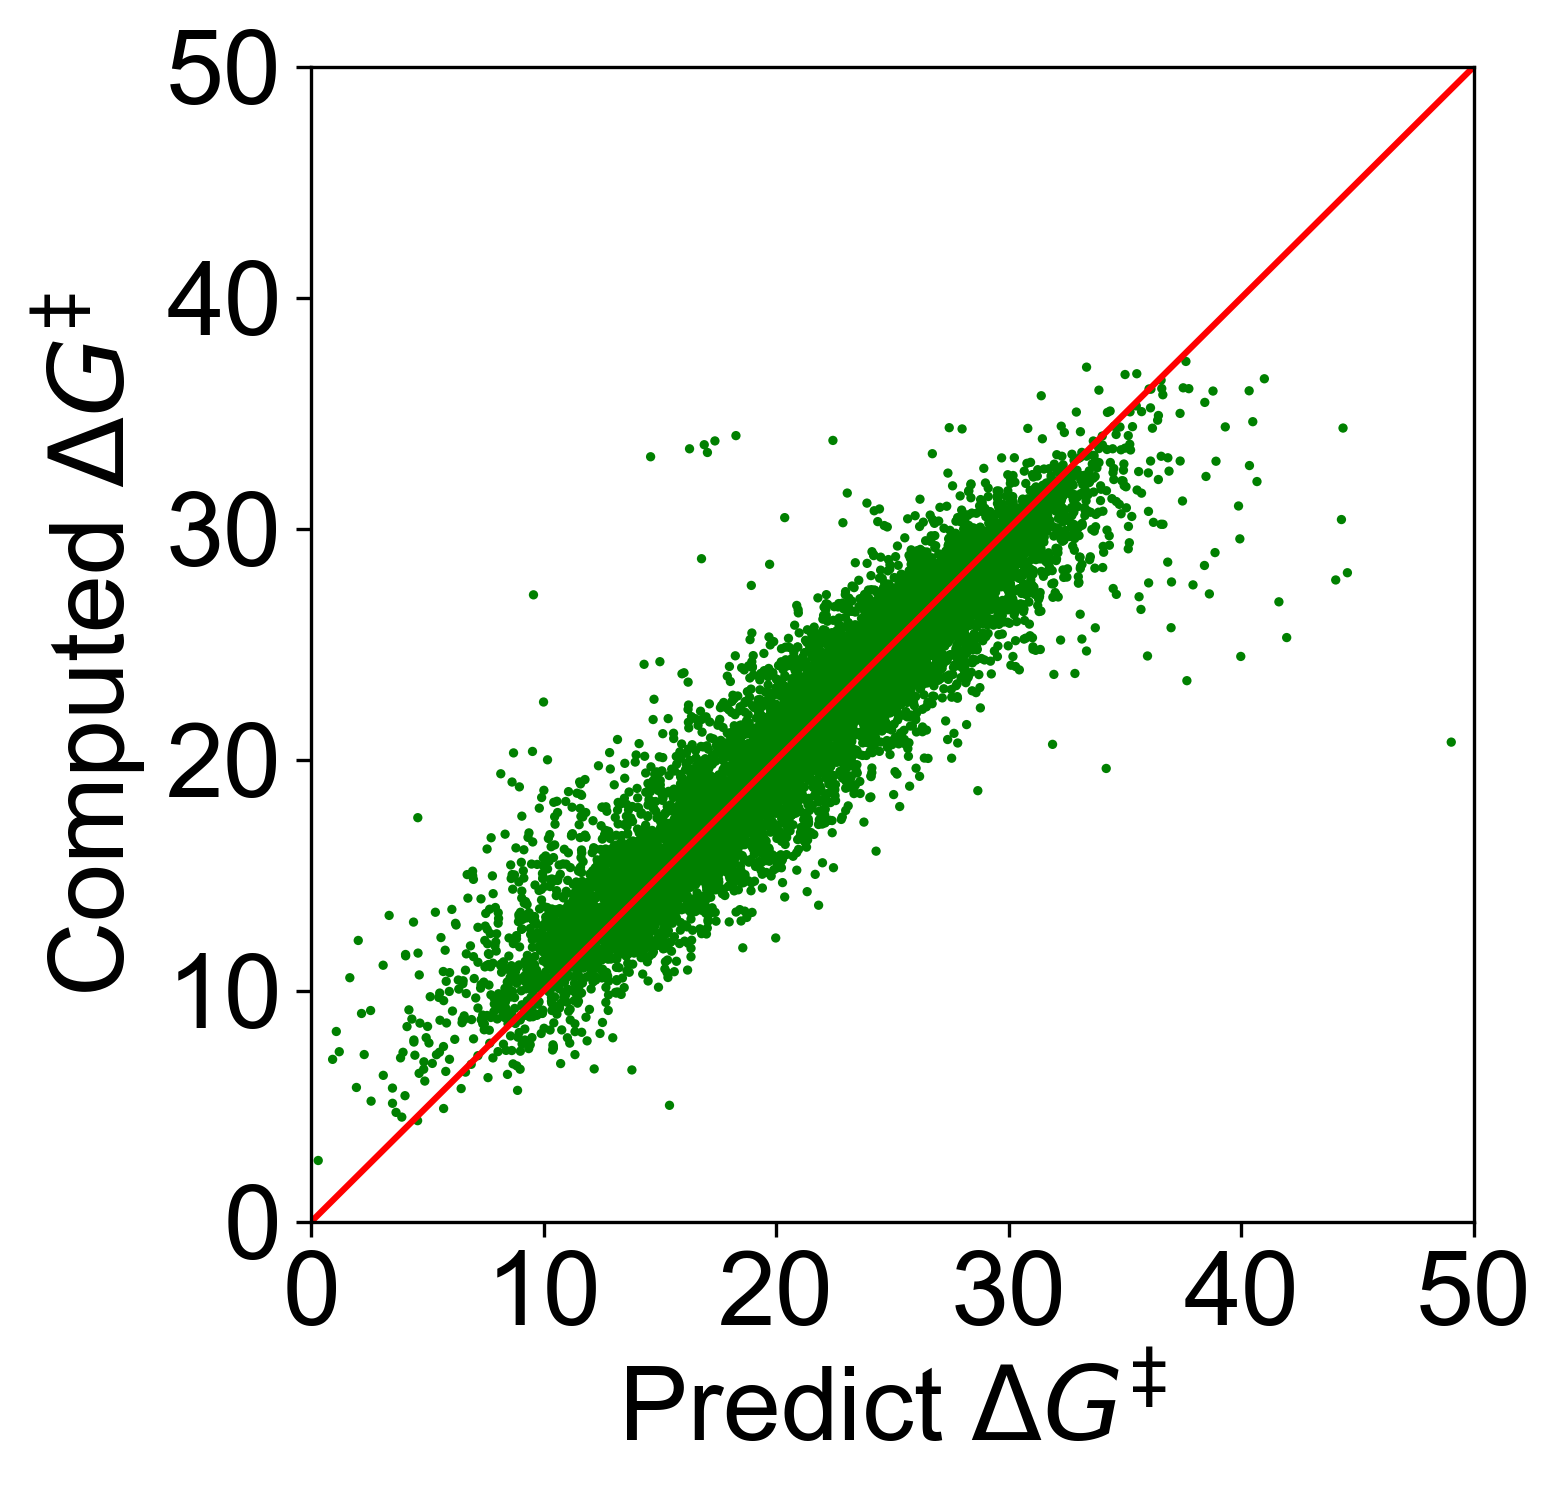

In [29]:
LB_Indexs = np.sort(data_csv['N_Index'].unique())
kf = KFold(n_splits=5, shuffle=True, random_state=0)
all_r2s, all_maes = [], []
all_pred = []
all_real = []
for i, (train_index, test_index) in enumerate(kf.split(LB_Indexs)):
    train_LB_index = LB_Indexs[train_index]
    test_LB_index = LB_Indexs[test_index]
    train_df = data_csv.loc[data_csv['N_Index'].isin(train_LB_index)].reset_index(drop=True)
    test_df = data_csv.loc[data_csv['N_Index'].isin(test_LB_index)].reset_index(drop=True)
    train_X = dataframe_to_descriptors(train_df, B_N_des_map, Cl_des_map, duplicate_cl_ids=duplicate_Cl_id)
    test_X = dataframe_to_descriptors(test_df, B_N_des_map, Cl_des_map, duplicate_cl_ids=duplicate_Cl_id)
    train_y = train_df['deltaGa(kcal/mol)']
    test_y = test_df['deltaGa(kcal/mol)']   

    model = CatBoostRegressor(iterations=10000, learning_rate=0.01, depth=6, verbose=0, random_state = 0)
    model.fit(train_X, train_y)
    y_pred = model.predict(test_X)
    all_r2s.append(r2_score(test_y, y_pred))
    all_maes.append(mean_absolute_error(test_y, y_pred))
    all_pred.extend(y_pred)
    all_real.extend(test_y.to_numpy())
print("R2:", np.mean(all_r2s), "MAE:", np.mean(all_maes))
plot_scatter_with_metrics(np.array(all_real), np.array(all_pred), min_=0, max_=50)
